<a href="https://colab.research.google.com/github/doperjerr/Part1-Text_Analytics69/blob/main/part_1_Text_Analytics69.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

นางสาวณัฐธิดา จันทโสภา 673020044-1

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [ ]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
# def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)

In [4]:
import json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------
# 1. Improved Generator function (รองรับทั้ง JSONL และ JSON Array)
# ---------------------------------------------
def iter_jsonl(path):
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # ข้ามบรรทัดว่าง หรือวงเล็บเปิด/ปิดของ JSON Array
            if not line or line in ('[', ']'):
                continue
            # ตัดคอมม่าท้ายบรรทัดออก (กรณีไฟล์เป็น JSON Array แต่ละบรรทัดคั่นด้วยคอมม่า)
            if line.endswith(','):
                line = line[:-1]

            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                # ข้ามบรรทัดที่เกิดข้อผิดพลาดหรือไม่สามารถแปลงเป็น JSON ได้
                continue

# เปลี่ยน path เป็นไฟล์ของคุณ (เช่นไฟล์ .json หรือ .jsonl ที่ดาวน์โหลดมา)
file_path = "posts_20241127_150757.jsonl"

data = []
# อ่านข้อมูลผ่าน generator
for i, post in enumerate(iter_jsonl(file_path)):
    data.append({
        'text': post.get('text', ''),
        'created_at': post.get('created_at', ''),
        'author': post.get('author', ''),
        'uri': post.get('uri', ''),
        'has_images': post.get('has_images', False),
        'reply_to': post.get('reply_to', None),
        'predicted_language': post.get('predicted_language', 'unknown')
    })

    # หากต้องการทดสอบรันแค่บางส่วนก่อน (เช่น 50,000 แถวแรก) สามารถเปิดบรรทัดนี้ได้
    # if i >= 50000: break

df = pd.DataFrame(data)
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
print(f"Loaded {len(df)} rows successfully!")

Loaded 91851 rows successfully!


/tmp/ipykernel_3372/1538760761.py:47: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


In [6]:
df.head()

,text,created_at,author,uri,has_images,reply_to,predicted_language
0,My one write word today is 'Thankful'. The lit...,2024-11-27 15:07:52.648000+00:00,did:plc:g3bdhte53n3b5uzd5ea2zzsh,at://did:plc:g3bdhte53n3b5uzd5ea2zzsh/app.bsky...,True,None,unknown
1,Careful! Talk like that on this side of the At...,2024-11-27 15:07:54.838000+00:00,did:plc:xzqomtbik5url7dfbyonmeoc,at://did:plc:xzqomtbik5url7dfbyonmeoc/app.bsky...,False,at://did:plc:dce6oclornits7ergyscjf5j/app.bsky...,unknown
2,Reading 'Download a Free Magento Theme: HelloW...,2010-06-12 16:54:17+00:00,did:plc:id2rbt2kysdnscdrzh5o5n7d,at://did:plc:id2rbt2kysdnscdrzh5o5n7d/app.bsky...,False,None,unknown
3,Pick any topic that concerns you. Election int...,2024-11-27 15:07:56.213000+00:00,did:plc:ziopqwph3ocpt6mfst4g75g3,at://did:plc:ziopqwph3ocpt6mfst4g75g3/app.bsky...,False,at://did:plc:kfwtulbx4xrbhvbqvr6utlwf/app.bsky...,unknown
4,Il a pas dit ce qu'il mettait à la place,2024-11-27 15:07:56.168000+00:00,did:plc:enc7q2wak7brynoqkddq7jb4,at://did:plc:enc7q2wak7brynoqkddq7jb4/app.bsky...,False,at://did:plc:6xy23uaatgz25qigwqf65ph6/app.bsky...,unknown


In [10]:
# ---------------------------------------------
# Answer Question 1: คนโพสต์เมื่อไร
# ---------------------------------------------
# แปลงข้อมูลเป็น Datetime และกรองแถวที่แปลงไม่สำเร็จ (ที่เป็น NaT/Null) ทิ้ง
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df_valid = df.dropna(subset=['created_at']).copy()

total_posts = len(df)
min_time = df_valid['created_at'].min()
max_time = df_valid['created_at'].max()

df_valid['hour'] = df_valid['created_at'].dt.hour
peak_hour = df_valid['hour'].mode()[0] if not df_valid['hour'].empty else None

print(f"Total Posts: {total_posts}")
print(f"Time Range: {min_time} to {max_time}")
print(f"Peak Posting Hour: {peak_hour}:00")

Total Posts: 91851
Time Range: 2010-03-28 21:25:10+00:00 to 2024-11-28 10:12:49.798000+00:00
Peak Posting Hour: 15:00


In [11]:
# ---------------------------------------------
# Answer Question 2: ใช้ภาษาอะไร
# ---------------------------------------------
lang_counts = df['predicted_language'].value_counts(normalize=True) * 100
print("\nLanguage Proportions (%):")
print(lang_counts.head(5))


Language Proportions (%):
predicted_language
unknown    100.0
Name: proportion, dtype: float64


เนื่องจากข้อมูลถูกบันทึกเป็นค่าว่างหรือตรวจจับภาษาไม่ได้ทั้งหมด จึงยังไม่สามารถระบุภาษาหลักที่ใช้งานจริงจากชุดข้อมูลนี้ได้อย่างชัดเจน จำเป็นต้องตรวจสอบการเก็บฟิลด์ภาษาเพิ่มเติมหากต้องการเจาะจงกลุ่มเป้าหมายด้านภาษา

In [12]:
# ---------------------------------------------
# Answer Question 3: คนพูดถึงอะไร (Hashtags/Keywords)
# ---------------------------------------------
import re
all_text = " ".join(df['text'].dropna().astype(str))
hashtags = re.findall(r"#\w+", all_text)
top_hashtags = Counter(hashtags).most_common(5)
print("\nTop Hashtags:", top_hashtags)



Top Hashtags: [('#Fiona', 333), ('#art', 252), ('#eduinov', 167), ('#hamradio', 108), ('#nsfw', 103)]


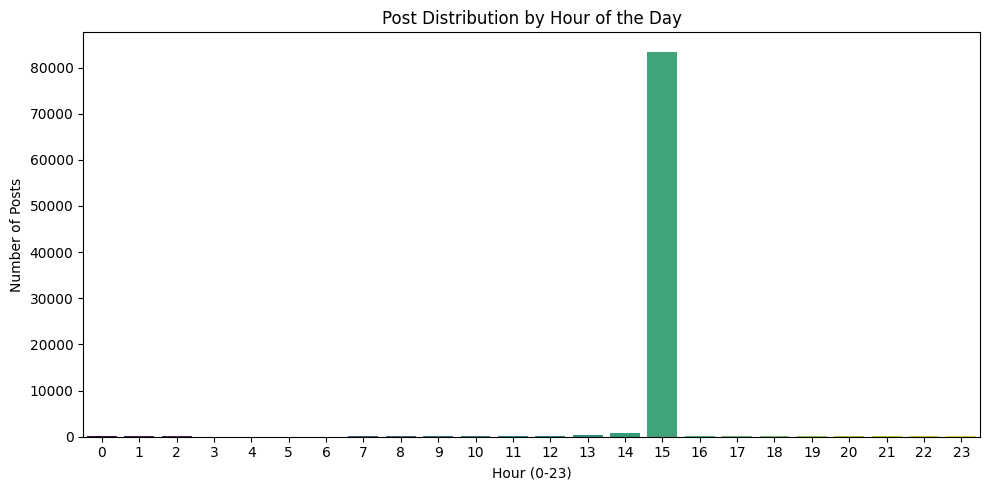

In [14]:
# ---------------------------------------------
# Answer Question 4: Visualization & Limitations
# ---------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df_valid, x='hour', order=range(24), palette='viridis', hue='hour', legend=False)

plt.title('Post Distribution by Hour of the Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.savefig('posts_by_hour.png')
plt.show()

ข้อมูลชุดนี้มีช่วงเวลากว้างมาก (ตั้งแต่ปี 2010 ถึง 2024) แต่มีความหนาแน่นของโพสต์ในแต่ละช่วงที่ไม่สม่ำเสมอ จึงอาจไม่สามารถนำมาสะท้อนพฤติกรรมปัจจุบันของผู้ใช้งานในภาพรวมทั้งหมดได้อย่างแม่นยำ และฟิลด์ภาษาแสดงผลเป็นค่า unknown ทั้งหมด ทำให้ไม่สามารถนำข้อมูลชุดนี้ไปวิเคราะห์สัดส่วนหรือความต้องการด้านภาษาของผู้ใช้งานในเชิงลึกได้

**<สรุปสั้น ๆ ถึงลูกค้า 5 บรรทัด>**

* ข้อมูลทั้งหมดมีจำนวน 91,851 โพสต์ ครอบคลุมตั้งแต่ปี 2010 ถึง 2024 โดยมีช่วงเวลาที่คนโพสต์หนาแน่นที่สุดคือเวลา 15:00 น
* สัดส่วนภาษาในชุดข้อมูลปรากฏเป็นค่า unknown ทั้งหมด 100% จึงยังไม่สามารถระบุภาษาหลักที่ใช้งานจริงได้
* แฮชแท็กหรือคำวลีเด่นที่ผู้คนพูดถึงมากที่สุด 3 อันดับแรก ได้แก่ #Fiona, #art และ #eduinov ตามลำดับ
* ข้อมูลเชิงภาพ (Visualization) แสดงให้เห็นการกระจุกตัวของการโพสต์อย่างเด่นชัดในช่วงบ่าย (15:00 น.)
* ข้อจำกัดของข้อมูลคือช่วงเวลาไม่สม่ำเสมอ ขาดข้อมูลด้านภาษา และเป็นเพียงกลุ่มตัวอย่างสาธารณะที่ไม่สามารถสะท้อนพฤติกรรมประชากรศาสตร์ทั้งหมดได้